In [1]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#23456789
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import SGD
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary

## Initializing Tensors

In [2]:
x = torch.tensor([[1, 2]])
y = torch.tensor([[1], [2]])
print(x.shape)
print(y.shape)
print(x.dtype)

torch.Size([1, 2])
torch.Size([2, 1])
torch.int64


In [3]:
x = torch.tensor([False, 1, 2.])
x

tensor([0., 1., 2.])

In [4]:
torch.zeros((3, 4))

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [5]:
torch.ones((2, 3))

tensor([[1., 1., 1.],
        [1., 1., 1.]])

In [6]:
torch.randint(low=0, high=10, size=(3, 2))

tensor([[2, 6],
        [5, 7],
        [8, 9]])

In [7]:
torch.rand(2, 4)

tensor([[0.6434, 0.3188, 0.4001, 0.5176],
        [0.2377, 0.8982, 0.7184, 0.9992]])

In [8]:
torch.randn((3, 4))  # normal

tensor([[-1.1295, -0.8114,  0.1873, -1.5667],
        [-0.4582, -0.9112, -1.0975, -0.3205],
        [ 0.7077, -0.0821,  1.3246,  1.1319]])

In [9]:
x = np.array([[10, 20, 30], [2, 3, 4]])
y = torch.tensor(x)
y

tensor([[10, 20, 30],
        [ 2,  3,  4]])

In [10]:
type(x), type(y)

(numpy.ndarray, torch.Tensor)

## Operations on Tensors

In [11]:
x = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8]])
10 * x

tensor([[10, 20, 30, 40],
        [50, 60, 70, 80]])

In [12]:
y = x + 10
y

tensor([[11, 12, 13, 14],
        [15, 16, 17, 18]])

In [13]:
y.shape

torch.Size([2, 4])

In [14]:
y = y.view(4, 2)  # reshape
y

tensor([[11, 12],
        [13, 14],
        [15, 16],
        [17, 18]])

In [15]:
x = torch.randn(3, 1, 3)
z1 =  torch.squeeze(x, 1)
z2 = torch.squeeze(x)  # only one possible dim to squeeze out
x.shape, z1.shape, z2.shape

(torch.Size([3, 1, 3]), torch.Size([3, 3]), torch.Size([3, 3]))

In [16]:
x = torch.randn(3, 3)
z1 = x.unsqueeze(0)
z2 = x.unsqueeze(1)
x.shape, z1.shape, z2.shape

(torch.Size([3, 3]), torch.Size([1, 3, 3]), torch.Size([3, 1, 3]))

In [17]:
x = torch.tensor([[1, 2, 3, 4], [5, 6, 7, 8]])
x @ y

tensor([[150, 160],
        [374, 400]])

In [18]:
torch.matmul(x, y)

tensor([[150, 160],
        [374, 400]])

In [19]:
x = torch.randn(10, 10, 10)
z1 = torch.cat([x, x], axis=0)
z2 = torch.cat([x, x], axis=1)
z1.shape, z2.shape

(torch.Size([20, 10, 10]), torch.Size([10, 20, 10]))

In [20]:
x = torch.arange(25).reshape(5, 5)
x.max()

tensor(24)

In [21]:
x.max(dim=0)

torch.return_types.max(
values=tensor([20, 21, 22, 23, 24]),
indices=tensor([4, 4, 4, 4, 4]))

In [22]:
m, argm = x.max(dim=1)
m, argm

(tensor([ 4,  9, 14, 19, 24]), tensor([4, 4, 4, 4, 4]))

In [23]:
x = torch.randn(10, 20, 30)
z = x.permute(2, 0, 1)
x.shape, z.shape

(torch.Size([10, 20, 30]), torch.Size([30, 10, 20]))

## Auto Gradients of Tensor Objects

In [24]:
x = torch.tensor([[2., -1.], [1., 1.]], requires_grad=True)
x

tensor([[ 2., -1.],
        [ 1.,  1.]], requires_grad=True)

In [25]:
out = x.pow(2).sum()  # sum of squares
out.backward()
x.grad

tensor([[ 4., -2.],
        [ 2.,  2.]])

out = x^2; grad = 2x

## Advantages of PyTorch's Tensors over Numpy's `ndarray`s

In [26]:
x = torch.rand(1, 6400)
y = torch.rand(6400, 5000)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [27]:
x, y = x.to(device), y.to(device)

In [28]:
%%timeit
z = x @ y

6.29 ms ± 350 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [29]:
x = np.random.random((1, 6400))
y = np.random.random((6400, 5000))

In [30]:
%%timeit
z = x @ y

6.5 ms ± 43.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Building a Neural Netwerk with PyTorch

In [31]:
x = [[1, 2], [3, 4], [5, 6], [7, 8]]
y = [[3], [7], [11], [15]]

In [32]:
X = torch.tensor(x).float()
y = torch.tensor(y).float()

In [33]:
X = X.to(device)
y = y.to(device)

In [34]:
class MyNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.Linear(2, 8)
        self.hidden_layer_activation = nn.ReLU()
        self.hidden_to_output_layer = nn.Linear(8, 1)

    def forward(self, x):
        x = self.input_to_hidden_layer(x)
        x = self.hidden_layer_activation(x)
        x = self.hidden_to_output_layer(x)
        return x

In [35]:
my_net = MyNN().to(device)

In [36]:
my_net.input_to_hidden_layer.weight

Parameter containing:
tensor([[ 0.0041, -0.1524],
        [-0.2991,  0.6490],
        [ 0.6097,  0.2732],
        [-0.4346,  0.6764],
        [ 0.1326,  0.1164],
        [-0.1096, -0.6881],
        [-0.3259, -0.1730],
        [ 0.6825,  0.5201]], requires_grad=True)

In [37]:
my_net.parameters()

<generator object Module.parameters at 0x113cdcf20>

In [38]:
for p in my_net.parameters():
    print(p)

Parameter containing:
tensor([[ 0.0041, -0.1524],
        [-0.2991,  0.6490],
        [ 0.6097,  0.2732],
        [-0.4346,  0.6764],
        [ 0.1326,  0.1164],
        [-0.1096, -0.6881],
        [-0.3259, -0.1730],
        [ 0.6825,  0.5201]], requires_grad=True)
Parameter containing:
tensor([ 0.6545,  0.5638,  0.0079,  0.2848,  0.5533,  0.2711, -0.3993,  0.3779],
       requires_grad=True)
Parameter containing:
tensor([[ 0.0988, -0.1333,  0.1548, -0.3117, -0.3470, -0.1456,  0.1816, -0.1420]],
       requires_grad=True)
Parameter containing:
tensor([0.0552], requires_grad=True)


In [39]:
# аlternate
class MyNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.Parameter(torch.rand(2, 8))
        self.hidden_layer_activation = nn.ReLU()
        self.hidden_to_output_layer = nn.Parameter(torch.rand(8, 1))

    def forward(self, x):
        x = x @ self.input_to_hidden_layer
        x = self.hidden_layer_activation(x)
        x = x @ self.hidden_to_output_layer
        return x

In [40]:
loss_func = nn.MSELoss()

In [41]:
_y = my_net(X)
loss_val = loss_func(_y, y)
loss_val

tensor(139.3947, grad_fn=<MseLossBackward0>)

In [42]:
opt = SGD(my_net.parameters(), lr=0.001)

In [43]:
# illustration
opt.zero_grad() 
loss_val = loss_func(my_net(X), y)
loss_val

tensor(139.3947, grad_fn=<MseLossBackward0>)

In [44]:
loss_val.backward()
opt.step()

In [45]:
loss_history = []
for _ in range(50):
    opt.zero_grad()
    loss_val = loss_func(my_net(X), y)
    loss_val.backward()
    opt.step()
    loss_history.append(loss_val.item())

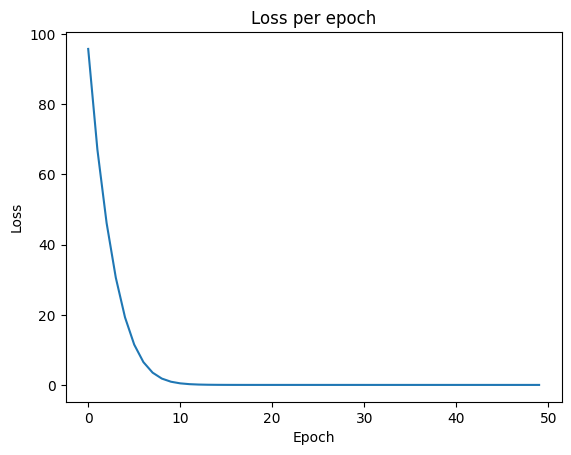

In [46]:
plt.plot(loss_history)
plt.title('Loss per epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss');

In [47]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
x = [[1, 2], [3, 4], [5, 6], [7, 8]]
y = [[3], [7], [11], [15]]
X = torch.tensor(x).float()
y = torch.tensor(y).float()
X = X.to(device)
y = y.to(device)

In [48]:
class MyDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x).float()
        self.y = torch.tensor(y).float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        return self.x[i], self.y[i]

In [49]:
ds = MyDataset(X, y)
dl = DataLoader(ds, batch_size=2, shuffle=True)
for x, y in dl:
    print(f'{x} -> {y}')

tensor([[3., 4.],
        [1., 2.]]) -> tensor([[7.],
        [3.]])
tensor([[7., 8.],
        [5., 6.]]) -> tensor([[15.],
        [11.]])


/var/folders/41/jhvt_zmd3nz3x5jsqblr221r0000gn/T/ipykernel_58993/1595280489.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.x = torch.tensor(x).float()
/var/folders/41/jhvt_zmd3nz3x5jsqblr221r0000gn/T/ipykernel_58993/1595280489.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y).float()


In [50]:
class MyNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.Linear(2, 8)
        self.hidden_layer_activation = nn.ReLU()
        self.hidden_to_output_layer = nn.Linear(8, 1)

    def forward(self, x):
        x = self.input_to_hidden_layer(x)
        x = self.hidden_layer_activation(x)
        x = self.hidden_to_output_layer(x)
        return x

In [51]:
my_net = MyNN().to(device)
loss_func = nn.MSELoss()
opt = SGD(my_net.parameters(), lr=0.001)

In [52]:
loss_history = []
start = time.time()
for _ in range(50):
    for x, y in dl:
        opt.zero_grad()
        loss = loss_func(my_net(x), y)
        loss.backward()
        opt.step()
        loss_history.append(loss.item())
end = time.time()
print(end - start)

0.01363372802734375


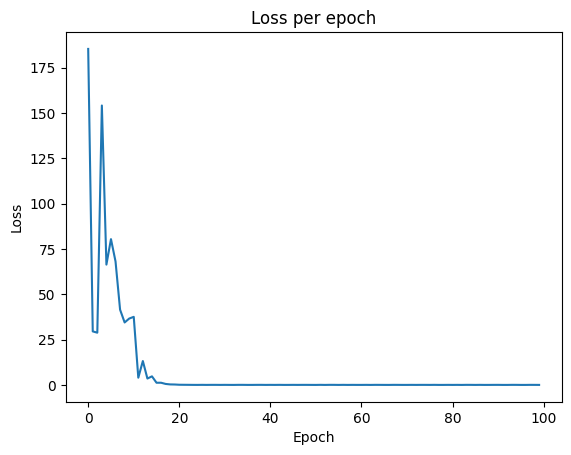

In [53]:
plt.plot(loss_history)
plt.title('Loss per epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss');

## Predicting from New Data Points

In [54]:
val_x = [[10, 11]]
val_x = torch.tensor(val_x).float().to(device)
my_net(val_x)

tensor([[21.3063]], grad_fn=<AddmmBackward0>)

## Implementing a Custom Loss Function

In [55]:
x = [[1, 2], [3, 4], [5, 6], [7, 8]]
y = [[3], [7], [11], [15]]

X = torch.tensor(x).float()
y = torch.tensor(y).float()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

X = X.to(device)
y = y.to(device)

In [56]:
class MyDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x).float()
        self.y = torch.tensor(y).float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, i):
        return self.x[i], self.y[i]

In [57]:
ds = MyDataset(X, y)
dl = DataLoader(ds, batch_size=2, shuffle=True)

/var/folders/41/jhvt_zmd3nz3x5jsqblr221r0000gn/T/ipykernel_58993/1595280489.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.x = torch.tensor(x).float()
/var/folders/41/jhvt_zmd3nz3x5jsqblr221r0000gn/T/ipykernel_58993/1595280489.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y).float()


In [58]:
class MyNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_to_hidden_layer = nn.Linear(2, 8)
        self.hidden_layer_activation = nn.ReLU()
        self.hidden_to_output_layer = nn.Linear(8, 1)

    def forward(self, x):
        x = self.input_to_hidden_layer(x)
        x = self.hidden_layer_activation(x)
        x = self.hidden_to_output_layer(x)
        return x

In [59]:
my_net = MyNN().to(device)

In [60]:
def my_rmse(yhat, y):
    loss = np.sqrt(((yhat - y) ** 2).mean().detach().numpy())
    return loss

In [61]:
loss_func = nn.MSELoss()
loss_val = loss_func(my_net(X), y)
loss_val, np.sqrt(loss_val.detach().numpy())

(tensor(99.1231, grad_fn=<MseLossBackward0>), np.float32(9.956059))

In [62]:
my_rmse(my_net(X), y)

np.float32(9.956059)

## Fetching Values of Intermediate Layers

In [63]:
input_to_hidden = my_net.input_to_hidden_layer(X)
hidden_activation = my_net.hidden_layer_activation(input_to_hidden)
hidden_activation

tensor([[1.1587, 0.0000, 0.0312, 0.0000, 0.8586, 0.0000, 1.1157, 0.0293],
        [3.0181, 0.0000, 0.0000, 0.0000, 1.9263, 0.0000, 2.3344, 0.2675],
        [4.8775, 0.0000, 0.0000, 0.0000, 2.9940, 0.0000, 3.5530, 0.5056],
        [6.7369, 0.0000, 0.0000, 0.0000, 4.0617, 0.0000, 4.7717, 0.7438]],
       grad_fn=<ReluBackward0>)

In [64]:
# alternately, in MyNN.forward(..): ....return output, hidden

## Using Sequential Method to Build a NN

In [65]:
x = [[1, 2], [3, 4], [5, 6], [7, 8]]
y = [[3], [7], [11], [15]]
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [66]:
class MyDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x).float().to(device)
        self.y = torch.tensor(y).float().to(device)

    def __getitem__(self, i):
        return self.x[i], self.y[i]

    def __len__(self):
        return len(self.x)
    

In [67]:
ds = MyDataset(x, y)
dl = DataLoader(ds, batch_size=2, shuffle=True)

In [68]:
mod = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1)).to(device)

In [69]:
summary(mod, torch.zeros(1, 2));

Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 8]                   24
├─ReLU: 1-2                              [-1, 8]                   --
├─Linear: 1-3                            [-1, 1]                   9
Total params: 33
Trainable params: 33
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


In [70]:
loss_func = nn.MSELoss()
opt = SGD(mod.parameters(), lr=0.001)

In [71]:
history = []
start = time.time()
for _ in range(50):
    for x, y in dl:
        opt.zero_grad()
        loss = loss_func(mod(x), y)
        loss.backward()
        opt.step()
        history.append(loss.item())
print(time.time() - start)

0.043708086013793945


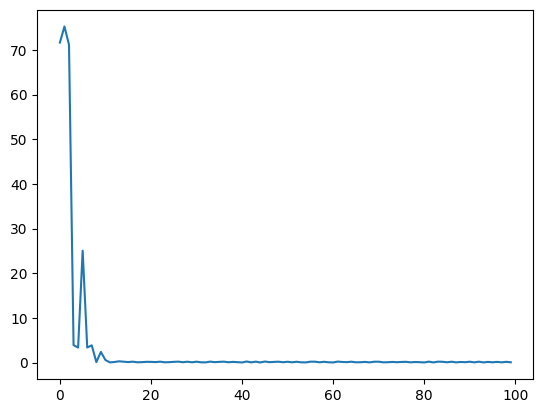

In [72]:
plt.plot(history);

In [73]:
valid = [[8, 9], [10, 11], [1.5, 2.5]]
mod(torch.tensor(valid).float().to(device))

tensor([[16.6197],
        [20.3303],
        [ 4.4812]], grad_fn=<AddmmBackward0>)

### Saving and loading a PyTorch model

In [74]:
mod.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0095, -0.0830],
                      [ 0.7580,  0.4814],
                      [-0.6834, -0.0171],
                      [-0.4716,  0.3055],
                      [ 0.3167,  0.7218],
                      [ 0.5766,  0.6223],
                      [-0.4942, -0.6200],
                      [-0.4456, -0.5024]])),
             ('0.bias',
              tensor([ 0.0130,  0.1682, -0.0160,  0.1660,  0.6587,  0.0576,  0.3461,  0.4067])),
             ('2.weight',
              tensor([[-0.0764,  0.6199,  0.3236, -0.3557,  0.6819,  0.3159,  0.0069,  0.0737]])),
             ('2.bias', tensor([0.2185]))])

In [75]:
torch.save(mod.to('cpu').state_dict(), 'my_model.pth')

In [76]:
mod = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1)).to(device)
state_dict = torch.load('my_model.pth')
mod.load_state_dict(state_dict)
mod.to(device)
mod(torch.tensor(valid).float().to(device))

tensor([[16.6197],
        [20.3303],
        [ 4.4812]], grad_fn=<AddmmBackward0>)